In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import display,Image

import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langgraph.types import Command, interrupt
from langchain_core.messages import BaseMessage

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    google_api_key = os.getenv("GOOGLE_API_KEY")
)

In [5]:
class State(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

@tool
def add(a:float,b:float)->float:
    """Add two numbers"""
    return a+b

tool = [add]
tool_node = ToolNode(tool)

llm_with_tools = llm.bind_tools(tool)

def call_llm_model(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

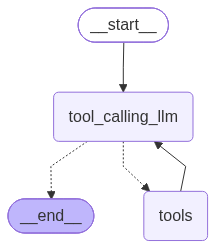

In [10]:
builder = StateGraph(State)

builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tool))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [7]:
response = graph.invoke({"messages" : "What is langsmith?"})

In [8]:
response

{'messages': [HumanMessage(content='What is langsmith?', additional_kwargs={}, response_metadata={}, id='25b49c0a-f59b-4e30-a33e-9f40c36fde62'),
  AIMessage(content=[{'type': 'text', 'text': '**LangSmith** is a unified platform developed by **LangChain** designed to help developers debug, test, evaluate, and monitor applications built using Large Language Models (LLMs).\n\nThink of it as a "command center" or a "flight recorder" for your AI applications. Because LLM applications are non-deterministic (they can produce different outputs for the same input) and complex (they involve multiple chains, retrievers, and tools), it is often very difficult to see exactly what is happening inside the "black box." LangSmith makes that process transparent.\n\nHere are the four core pillars of what LangSmith does:\n\n### 1. Debugging and Tracing\nWhen you are building an LLM app, it’s hard to see the internal steps (e.g., "Why did it fetch that specific document?" or "Why did the model hallucinate 

In [11]:
response2 = graph.invoke({"messages" : "what is 5 + 24"})
response2

{'messages': [HumanMessage(content='what is 5 + 24', additional_kwargs={}, response_metadata={}, id='f56e3b03-9b08-42cd-bf81-a66851000593'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"a": 5, "b": 24}'}, '__gemini_function_call_thought_signatures__': {'call_1897886': 'EnEKbwERTTIP2LE28D69SGzR1hbRJkFXv+fP8B6Zhbwe6ecITr+Ok6uoWvQ3QOXbwSMX5M3KKEYplWKDo21rENQwTE6rimwXpHYAq2Xl7RxEHYFENfHQX42kKnjcAa9mYZWCLns/pl4PwyoVPHcdRSBbaQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00fd7-4698-7752-b995-56abec009020-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 24}, 'id': 'call_1897886', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 17, 'total_tokens': 76, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='29.0', name='add', id='8b9c8a49-bce2-488c-9d31-e37012bf1b6c', 